# Trabajo Práctico: Primera Entrega - Analítica para la Toma de Decisiones II
**Profesor:** David Cardona Vásquez  
**Fecha:** Agosto 2026  

<div align="left">
    <h2><b>Integrantes:<h2>
    <p>Alexandra Daniela Velez De La Hoz<p>
    <p>Liz Dayana Rojas Cortes<p>
    <p>Eddy Santiago Velez Monterroza<p>


---
## Descripción del Notebook
Este entorno ejecutable procesa los archivos del sistema logístico (`loads.csv`, `routes.csv`, `drivers.csv`, `delivery_events.csv`, `facilities.csv`, `customers.csv`, `fuel_purchases.csv`, `maintenance_records.csv`, `driver_monthly_metrics.csv`) y desarrolla las 4 partes requeridas:
1. **Parte 1: Analítica Descriptiva** (Cruce de tablas, caracterización de carga, análisis de conductores y análisis geográfico/retención).
2. **Parte 2: Aprendizaje Supervisado - Clasificación** (Modelo para predecir retrasos en entregas `is_delayed`).
3. **Parte 3: Aprendizaje Supervisado - Regresión** (Modelo para predecir ingresos `revenue` según peso y distancia).
4. **Parte 4: Visión de Negocio y Ética** (Conclusiones prescriptivas y análisis ético de sesgos).

In [2]:
# Librerías para análisis, preprocesamiento y modelado
# se importan las librerías fundamentales para manipulación de datos y operaciones matemáticas

import pandas as pd
import numpy as np
# se importan las herramientas de visualización gráfica
import matplotlib.pyplot as plt
import seaborn as sns

# se importan módulos de scikit-learn para machine learning y métricas de evaluación
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
# se configura la estética global, tamaño (9x5) y fuente (11) de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

# definimos una semilla fija para garantizar la reproducibilidad de los cálculos aleatorios
RANDOM_STATE = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## Parte 1: Analítica Descriptiva

### Paso 1.1: Carga y Cruce de Tablas (Merge/Join)
Cargamos los DataFrames principales y realizamos los cruces relacionales a través de sus llaves primarias y foráneas.

In [6]:
# cargamos las tablas utilizadas en el análisis.
# cargamos los archivos CSV desde GITHUB en estructuras DataFrame, usando pandas

df_loads = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/loads.csv")
df_routes = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/routes.csv")
df_drivers = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/drivers.csv")
df_trips = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/trips.csv")
df_events = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/delivery_events.csv")
df_facilities = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/facilities.csv")
df_incidents = pd.read_csv("https://raw.githubusercontent.com/Eddys-base/Analitica-II/refs/heads/main/safety_incidents.csv")

# Peso e indicador económico por carga.
df_loads = df_loads.copy()

# Creamos una nueva columna convirtiendo el peso original de libras a kilogramos
df_loads["weight_kg"] = df_loads["weight_lbs"] * 0.45359237

# Calculamos el ingreso por kilogramo, asignando NaN si el peso es 0 para evitar error matemático
df_loads["revenue_per_kg"] = np.where(
    df_loads["weight_kg"] > 0,
    df_loads["revenue"] / df_loads["weight_kg"],
    np.nan,
)

# Resumen de eventos por carga. Un valor faltante se conserva como desconocido;
# no se interpreta automáticamente como una entrega a tiempo.
# Agrupa los eventos por 'load_id' para calcular tiempo de retención, puntualidad y cantidad de eventos
df_events_summary = (
    df_events.groupby("load_id", as_index=False)
    .agg(
        detention_minutes=("detention_minutes", "mean"),
        on_time_flag=("on_time_flag", "min"),
        event_count=("event_id", "count"),
    )
)

# Unimos la tabla principal de cargas con la de rutas y el resumen de eventos
df_completo = (
    df_loads
    .merge(df_routes, on="route_id", how="left", validate="many_to_one")
    .merge(df_events_summary, on="load_id", how="left", validate="one_to_one")
)

# Creamos la variable objetivo de retraso invirtiendo 'on_time_flag' si existe dato (1 - puntualidad)
df_completo["is_delayed"] = np.where(
    df_completo["on_time_flag"].notna(),
    1 - df_completo["on_time_flag"],
    np.nan,
)
print("Estructura del DataFrame unificado:", df_completo.shape)
print("Cargas sin etiqueta de puntualidad:", int(df_completo["is_delayed"].isna().sum()))
display(df_completo.head(3))

Archivos cargados exitosamente desde GitHub.
Estructura del DataFrame unificado: (85410, 26)
Cargas sin etiqueta de puntualidad: 0


,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,...,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days,detention_minutes,on_time_flag,event_count,is_delayed
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,...,Detroit,MI,1271,2.33,0.32,2,115.0,False,2,1.0
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,...,Indianapolis,IN,519,2.27,0.19,1,64.5,False,2,1.0
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,...,Portland,OR,2332,2.69,0.34,4,47.0,True,2,0.0


### Paso 1.2: Análisis de Cargas
Caracterizamos los tipos de carga (`load_type`) e identificamos cuál genera el mayor ingreso (`revenue`) promedio por peso (`revenue_per_kg`).

--- Rendimiento por tipo de carga ---


,load_type,ingreso_promedio,peso_promedio_kg,ingreso_por_kg_promedio,ingreso_total,peso_total_kg,total_envios,ingreso_total_por_kg
1,Refrigerated,3072.859156,12454.746129,0.291023,1.319670e+08,5.348815e+08,42946,0.246722
0,Dry Van,3074.575899,12472.518602,0.291096,1.305588e+08,5.296330e+08,42464,0.246508


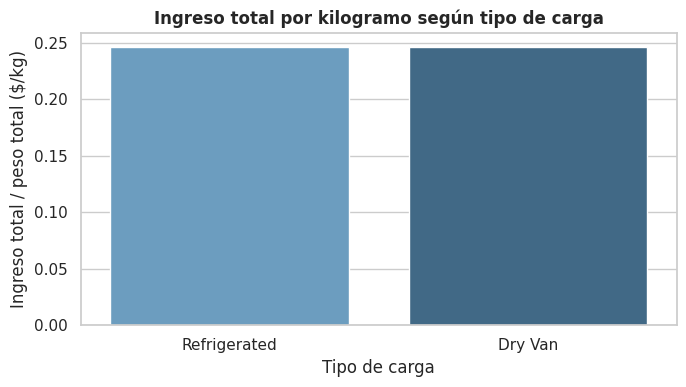

In [18]:
# Se muestran dos definiciones para evitar una conclusión dependiente de la forma
# de promediar: media del rendimiento individual y razón entre totales.
# Agrupamos los datos por tipo de carga y calcula promedios y sumas de ingresos y peso
analisis_carga = (df_completo.groupby("load_type", as_index=False).agg(
        ingreso_promedio=("revenue", "mean"),
        peso_promedio_kg=("weight_kg", "mean"),
        ingreso_por_kg_promedio=("revenue_per_kg", "mean"),
        ingreso_total=("revenue", "sum"),
        peso_total_kg=("weight_kg", "sum"),
        total_envios=("load_id", "nunique"),))

# Calculamos el rendimiento dividiendo el ingreso total entre el peso total por tipo de carga
analisis_carga["ingreso_total_por_kg"] = (
    analisis_carga["ingreso_total"] / analisis_carga["peso_total_kg"])
analisis_carga = analisis_carga.sort_values(
    "ingreso_total_por_kg", ascending=False)

print("--- Rendimiento por tipo de carga ---")
display(analisis_carga)

# Dibujamos un gráfico de barras mostrando el ingreso total por kilogramo para cada tipo de carga
plt.figure(figsize=(7, 4))
sns.barplot(
    data=analisis_carga,
    x="load_type",
    y="ingreso_total_por_kg",
    hue="load_type",
    legend=False,
    palette="Blues_d",)

plt.title("Ingreso total por kilogramo según tipo de carga", fontweight="bold")
plt.xlabel("Tipo de carga")
plt.ylabel("Ingreso total / peso total ($/kg)")
plt.tight_layout()
plt.show()

### Paso 1.3: Análisis de conductores

Se evalúan exactamente las dos relaciones solicitadas: experiencia frente a rutas operadas y experiencia frente a incidentes de seguridad. Los incidentes se vinculan con cada conductor mediante `trip_id`; por tanto, no se reemplazan por puntualidad ni por millas recorridas.


--- Experiencia e incidentes ---


,rango_experiencia,viajes,rutas_distintas,tasa_incidentes,incidentes_por_1000_viajes
0,Junior (0-5 años),15364,58,0.001692,1.692268
1,Intermedio (6-12 años),21405,58,0.001962,1.962158
2,Senior (>12 años),46927,58,0.002152,2.152279


--- Proporción de viajes en las 10 rutas más frecuentes ---


route_id,RTE00007,RTE00012,RTE00015,RTE00028,RTE00031,RTE00036,RTE00045,RTE00046,RTE00047,RTE00048
rango_experiencia,,,,,,,,,,
Junior (0-5 años),0.020047,0.019136,0.018550,0.017248,0.018224,0.018224,0.018810,0.018745,0.021153,0.018680
Intermedio (6-12 años),0.017613,0.016725,0.018080,0.017192,0.018781,0.017753,0.016819,0.017099,0.018267,0.018313
Senior (>12 años),0.016685,0.017559,0.017772,0.018135,0.016835,0.017794,0.017751,0.018113,0.018795,0.017495


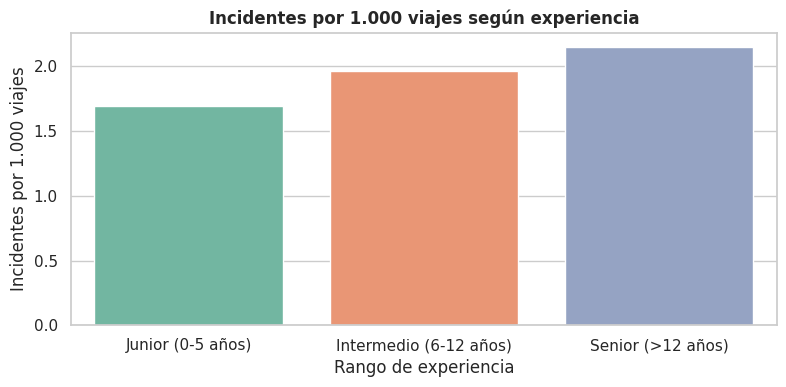

In [19]:
# Relacionar conductor, viaje, carga y ruta.
# se cruzan las tablas de viajes, cargas y conductores
driver_operations = (
    df_trips[["trip_id", "load_id", "driver_id"]]
    .merge(
        df_loads[["load_id", "route_id"]],
        on="load_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        df_drivers[["driver_id", "years_experience"]],
        on="driver_id",
        how="left",
        validate="many_to_one",))

# Un viaje cuenta como incidente si aparece al menos una vez en safety_incidents.
incident_trip_ids = set(df_incidents["trip_id"].dropna().unique())

# Asigna 1 si hubo incidente de seguridad en el viaje, 0 si no
driver_operations["has_incident"] = (
    driver_operations["trip_id"].isin(incident_trip_ids).astype(int))

# se segmenta la experiencia de los conductores en rangos (Junior, Intermedio, Senior)
driver_operations["rango_experiencia"] = pd.cut(
    driver_operations["years_experience"],
    bins=[-np.inf, 5, 12, np.inf],
    labels=["Junior (0-5 años)", "Intermedio (6-12 años)", "Senior (>12 años)"],)

# Calculamos la cantidad de viajes, rutas e incidentes por cada rango de experiencia
resumen_experiencia = (
    driver_operations.groupby("rango_experiencia", observed=True)
    .agg(
        viajes=("trip_id", "nunique"),
        rutas_distintas=("route_id", "nunique"),
        tasa_incidentes=("has_incident", "mean"),)
    .reset_index())
resumen_experiencia["incidentes_por_1000_viajes"] = (
    1000 * resumen_experiencia["tasa_incidentes"])

# Cre0mosa tabla de contingencia normalizada por filas para ver qué rutas se toman según experiencia
tabla_rutas = pd.crosstab(
    driver_operations["rango_experiencia"],
    driver_operations["route_id"],
    normalize="index",)
top_routes = driver_operations["route_id"].value_counts().head(10).index

print("--- Experiencia e incidentes ---")
display(resumen_experiencia)
print("--- Proporción de viajes en las 10 rutas más frecuentes ---")
display(tabla_rutas.loc[:, tabla_rutas.columns.intersection(top_routes)])

# Generamos gráfico de barras de incidentes por cada 1.000 viajes según rango de experiencia
plt.figure(figsize=(8, 4))
sns.barplot(
    data=resumen_experiencia,
    x="rango_experiencia",
    y="incidentes_por_1000_viajes",
    hue="rango_experiencia",
    legend=False,
    palette="Set2",)

plt.title("Incidentes por 1.000 viajes según experiencia", fontweight="bold")
plt.xlabel("Rango de experiencia")
plt.ylabel("Incidentes por 1.000 viajes")
plt.tight_layout()
plt.show()


### Paso 1.4: Análisis Geográfico y Tiempos de Retención
Exploramos la relación entre distancia de la ruta e ingresos generados, e identificamos las instalaciones con mayores tiempos de retención (`detention_minutes`).



Correlación de Pearson distancia-ingreso: 0.9291


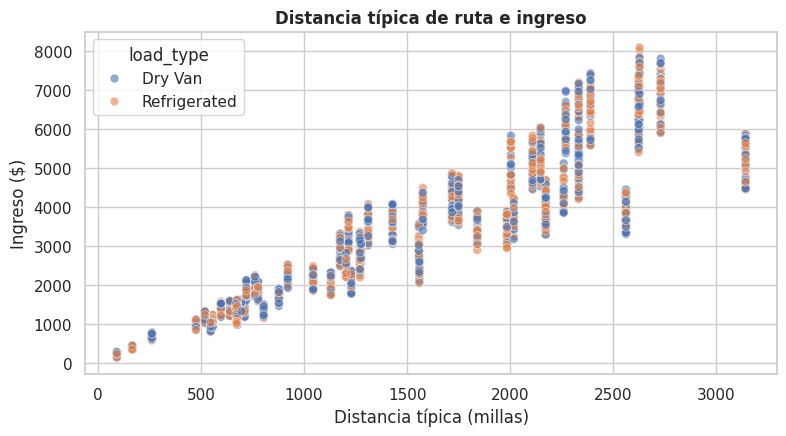

--- Top 5 instalaciones con mayor retención ---


,facility_id,facility_name,city,state,retencion_promedio_min,mediana_retencion_min,total_eventos
39,FAC00040,Nashville Distribution Center,Nashville,TN,93.799114,90.0,3385
14,FAC00015,Phoenix Distribution Center,Phoenix,AZ,93.677676,92.0,3391
47,FAC00048,Indianapolis Warehouse,Indianapolis,IN,93.612884,90.0,3384
13,FAC00014,Indianapolis Warehouse,Indianapolis,IN,93.581347,90.0,3399
41,FAC00042,Salt Lake City Terminal,Salt Lake City,UT,92.920501,90.0,3434


--- Top 5 rutas con mayor retención ---


,route_id,retencion_promedio_min,cargas
41,RTE00042,93.780581,1447
43,RTE00044,93.596454,1410
38,RTE00039,93.473958,1440
57,RTE00058,93.463687,1432
34,RTE00035,93.358779,1441


In [20]:
# Relación distancia-ingreso: visualización y medida cuantitativa.
geo_valid = df_completo[["typical_distance_miles", "revenue", "load_type"]].dropna()

# Calculamos la correlación estadística de Pearson entre la distancia típica y el ingreso
corr_dist_revenue = geo_valid["typical_distance_miles"].corr(geo_valid["revenue"])
print(f"Correlación de Pearson distancia-ingreso: {corr_dist_revenue:.4f}")

# Tomamos una muestra aleatoria (hasta 2000 datos) y traza gráfico de dispersión (distancia vs ingreso)
sample_size = min(2000, len(geo_valid))
geo_sample = geo_valid.sample(sample_size, random_state=RANDOM_STATE)
plt.figure(figsize=(8, 4.5))
sns.scatterplot(
    data=geo_sample,
    x="typical_distance_miles",
    y="revenue",
    hue="load_type",
    alpha=0.6,
    s=40,)
plt.title("Distancia típica de ruta e ingreso", fontweight="bold")
plt.xlabel("Distancia típica (millas)")
plt.ylabel("Ingreso ($)")
plt.tight_layout()
plt.show()

# Instalaciones con mayor retención; se exige un soporte mínimo para evitar
# que un único evento domine el ranking.
# Agrupamos eventos por instalación calculando la retención promedio y mediana
retencion_inst = (
    df_events.groupby("facility_id", as_index=False)
    .agg(
        retencion_promedio_min=("detention_minutes", "mean"),
        mediana_retencion_min=("detention_minutes", "median"),
        total_eventos=("event_id", "count"),))
min_eventos = 30
# Filtramos para considerar sólo instalaciones con al menos 30 eventos
retencion_top = (
    retencion_inst.query("total_eventos >= @min_eventos")
    .merge(df_facilities, on="facility_id", how="left", validate="many_to_one")
    .sort_values("retencion_promedio_min", ascending=False)
)

# Filtrmos rutas con al menos 30 cargas
retencion_ruta = (
    df_completo.groupby("route_id", as_index=False)
    .agg(
        retencion_promedio_min=("detention_minutes", "mean"),
        cargas=("load_id", "nunique"),
    )
    .query("cargas >= @min_eventos")
    .sort_values("retencion_promedio_min", ascending=False))

print("--- Top 5 instalaciones con mayor retención ---")
display(retencion_top[[
    "facility_id", "facility_name", "city", "state",
    "retencion_promedio_min", "mediana_retencion_min", "total_eventos"
]].head(5))
print("--- Top 5 rutas con mayor retención ---")
display(retencion_ruta.head(5))


---
## Parte 2: Aprendizaje Supervisado - Clasificación

### Objetivo
Predecir el retraso utilizando solamente información disponible antes de la entrega. `detention_minutes` se excluye porque se registra durante la operación y está estrechamente ligada al resultado. Las filas sin etiqueta conocida tampoco se convierten artificialmente en entregas puntuales.

El preprocesamiento se ajusta dentro de un `Pipeline`, únicamente con el conjunto de entrenamiento. Además de las métricas obligatorias, se informa el desempeño por clase para comprobar si la exactitud oculta un problema de desbalance.


Distribución de la variable objetivo:


,conteo
is_delayed,
1,60016
0,25394


,proporción
is_delayed,
1,0.702681
0,0.297319


--- Resultados de clasificación ---
Accuracy: 0.4996
ROC-AUC: 0.5009
              precision    recall  f1-score   support

    A tiempo       0.30      0.50      0.37      5079
   Retrasado       0.70      0.50      0.58     12003

    accuracy                           0.50     17082
   macro avg       0.50      0.50      0.48     17082
weighted avg       0.58      0.50      0.52     17082



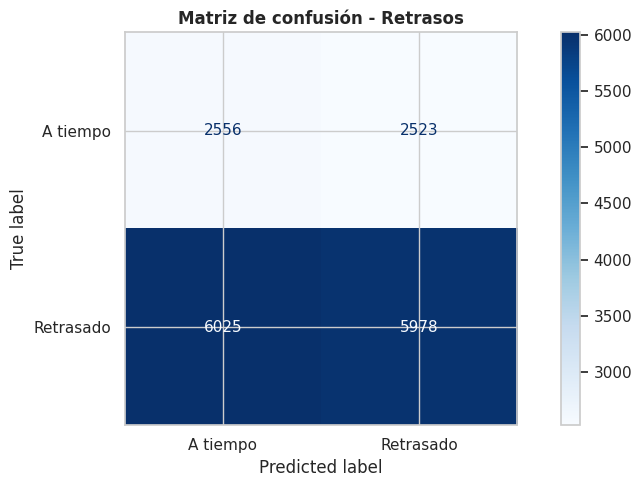

In [21]:
# Características disponibles antes de la entrega.
# Definimos las variables independientes a utilizar (peso, piezas, distancia, tarifa, combustible)
features_clf = [
    "weight_lbs",
    "pieces",
    "typical_distance_miles",
    "base_rate_per_mile",
    "fuel_surcharge_rate",
]

# Eliminamos filas sin etiqueta en la variable de retraso
clf_data = df_completo.dropna(subset=["is_delayed"]).copy()
X_clf = clf_data[features_clf]
y_clf = clf_data["is_delayed"].astype(int)

print("Distribución de la variable objetivo:")
display(y_clf.value_counts(dropna=False).rename("conteo").to_frame())
display(y_clf.value_counts(normalize=True).rename("proporción").to_frame())

if y_clf.nunique() != 2 or y_clf.value_counts().min() < 2:
    raise ValueError("La clasificación requiere dos clases con al menos dos observaciones cada una.")

# Dividimos en 80% entrenamiento y 20% prueba manteniendo proporción de clases (estratificación)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf,)

# Encadenmos imputación (mediana), escalado (StandardScaler) y modelo (Regresión Logística balanceada)
modelo_clf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight="balanced",
    )),])

# se entrena el pipeline completo usando datos de entrenamiento
modelo_clf.fit(X_train_c, y_train_c)

# Generamos predicciones (clases y probabilidades) sobre prueba
y_pred_c = modelo_clf.predict(X_test_c)
y_prob_c = modelo_clf.predict_proba(X_test_c)[:, 1]

# Calculamos métricas de evaluación del modelo de clasificación
acc_c = accuracy_score(y_test_c, y_pred_c)
auc_c = roc_auc_score(y_test_c, y_prob_c)
cm_c = confusion_matrix(y_test_c, y_pred_c)

print("--- Resultados de clasificación ---")
print(f"Accuracy: {acc_c:.4f}")
print(f"ROC-AUC: {auc_c:.4f}")
print(classification_report(y_test_c, y_pred_c, target_names=["A tiempo", "Retrasado"]))


# se grafica visualmente la matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=["A tiempo", "Retrasado"],
).plot(cmap="Blues")
plt.title("Matriz de confusión - Retrasos", fontweight="bold")
plt.tight_layout()
plt.show()


---
## Parte 3: Aprendizaje Supervisado - Regresión

### Objetivo
Predecir `revenue` a partir del peso y la distancia. Las observaciones sin variable objetivo se excluyen: el valor que el modelo debe aprender no debe inventarse mediante imputación.

El grado polinomial y la regularización se seleccionan mediante validación cruzada dentro del conjunto de entrenamiento. El conjunto de prueba se utiliza una sola vez para la evaluación final.


Mejores hiperparámetros: {'model__alpha': np.float64(0.1873817422860383), 'poly__degree': 2}
R2: 0.8616
MSE: 488,602.71
RMSE: $699.00
MAE: $502.38
MAPE (objetivos no nulos): 19.27%
Casos excluidos del MAPE por revenue=0: 0


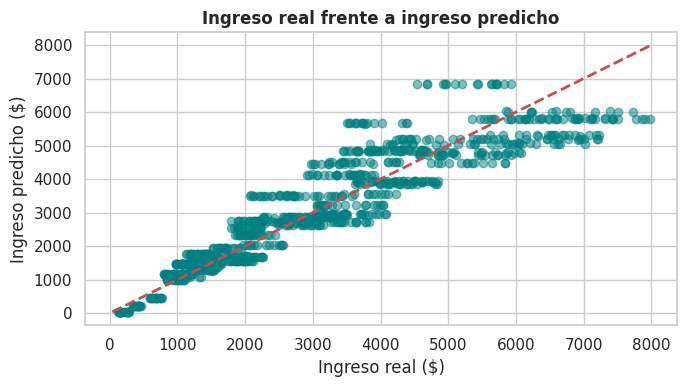

In [23]:
# se define peso y distancia como características para predecir ingreso
features_reg = ["weight_lbs", "typical_distance_miles"]
# Filtramos quitando registros que no tienen valor en la variable objetivo revenue
reg_data = df_completo.dropna(subset=["revenue"]).copy()
X_reg = reg_data[features_reg]
y_reg = reg_data["revenue"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,)

# Pipeline con imputación, características polinómicas, escalado y regresión Lasso
modelo_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000)),
])

param_grid = {
    "poly__degree": [1, 2],
    "model__alpha": np.logspace(-3, 2, 12),}

# Búsqueda exhaustiva de hiperparámetros con validación cruzada (5 folds)
busqueda_reg = GridSearchCV(
    modelo_reg,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,)

busqueda_reg.fit(X_train_r, y_train_r)
modelo_reg_final = busqueda_reg.best_estimator_
y_pred_r = modelo_reg_final.predict(X_test_r)

# Calculamos métricas de error de regresión
mse_r = mean_squared_error(y_test_r, y_pred_r)
rmse_r = np.sqrt(mse_r)
mae_r = mean_absolute_error(y_test_r, y_pred_r)
r2_r = r2_score(y_test_r, y_pred_r)

# MAPE solo donde el valor real es distinto de cero.
nonzero_mask = np.abs(y_test_r.to_numpy()) > np.finfo(float).eps
mape_r = np.mean(
    np.abs(
        (y_test_r.to_numpy()[nonzero_mask] - y_pred_r[nonzero_mask])
        / y_test_r.to_numpy()[nonzero_mask]
    )
) * 100

print("Mejores hiperparámetros:", busqueda_reg.best_params_)
print(f"R2: {r2_r:.4f}")
print(f"MSE: {mse_r:,.2f}")
print(f"RMSE: ${rmse_r:,.2f}")
print(f"MAE: ${mae_r:,.2f}")
print(f"MAPE (objetivos no nulos): {mape_r:.2f}%")
print("Casos excluidos del MAPE por revenue=0:", int((~nonzero_mask).sum()))

# Muestrear posiciones y usar las mismas posiciones en valores reales y predichos.
rng = np.random.default_rng(RANDOM_STATE)
plot_size = min(1000, len(y_test_r))
plot_positions = rng.choice(len(y_test_r), size=plot_size, replace=False)
y_real_plot = y_test_r.iloc[plot_positions].to_numpy()
y_pred_plot = y_pred_r[plot_positions]


# Gráfico de dispersión real vs predicho con línea de identidad
plt.figure(figsize=(7, 4))
plt.scatter(y_real_plot, y_pred_plot, alpha=0.5, color="teal")
lims = [min(y_real_plot.min(), y_pred_plot.min()), max(y_real_plot.max(), y_pred_plot.max())]
plt.plot(lims, lims, "r--", lw=2)
plt.title("Ingreso real frente a ingreso predicho", fontweight="bold")
plt.xlabel("Ingreso real ($)")
plt.ylabel("Ingreso predicho ($)")
plt.tight_layout()
plt.show()

# Parte 4: Visión de negocio y ética

## Interpretación y prescripción

### 1. Costo de falso negativo vs. falso positivo

En este caso, el costo de un **falso negativo** es alto, ya que ocurre cuando el modelo predice que una entrega llegará a tiempo, pero en realidad se retrasa. Esto puede ocasionar que la empresa reciba una penalización económica sin haber tenido la oportunidad de tomar medidas preventivas. Por otro lado, un **falso positivo**, es decir, predecir un retraso cuando finalmente la entrega llega a tiempo, representa un costo menor, principalmente asociado con un seguimiento o una intervención preventiva que no era necesaria.

Debido a esta diferencia en los costos, el modelo debería priorizar un **alto recall para la clase "Retrasado"**, con el objetivo de identificar la mayor cantidad posible de entregas que realmente presentarán retrasos.

### 2. Recall, Accuracy y ROC-AUC del clasificador

Los resultados obtenidos fueron **Accuracy = 0.4996, ROC-AUC = 0.5009 y Recall de la clase "Retrasado" = 0.50**. Estos valores se encuentran muy cercanos a los que se obtendrían mediante una predicción aleatoria, equivalente a lanzar una moneda al aire.

Aunque la precisión (*precision*) de la clase "Retrasado" fue de aproximadamente **0.70**, este resultado no representa necesariamente una capacidad predictiva real del modelo, sino que está influenciado por el **desbalance de las clases**, debido a que aproximadamente el 70 % de las entregas del conjunto de datos presentan retrasos.

Por lo tanto, el clasificador actual **no es suficientemente útil para tomar decisiones operativas**. Las variables utilizadas como peso, número de piezas, distancia, tarifa y recargo de combustible no parecen contener información suficiente para predecir de manera confiable si una entrega se retrasará.

Antes de implementar el modelo en un entorno productivo, sería necesario incorporar variables operativas adicionales, como el **historial del conductor, congestión de las instalaciones, día de la semana, condiciones climáticas y tráfico**, y posteriormente realizar una nueva evaluación de su capacidad predictiva.

### 3. MAE y MAPE de la regresión en términos financieros

El modelo de regresión obtuvo un **R² = 0.86, MAE = $502.38  y  MAPE = 19.27 %**. Esto indica que, en promedio, la predicción del ingreso por carga presenta una desviación aproximada de **$502**, equivalente a cerca del **19 % del valor real**.

Este nivel de error puede considerarse aceptable para realizar **proyecciones agregadas de ingresos por ruta o por periodo**, por ejemplo, como apoyo a la planeación financiera general. Sin embargo, no presenta la precisión suficiente para utilizarse directamente en procesos como **facturación individual o cotización directa a clientes**, donde se requiere un mayor nivel de exactitud.

### 4. Rutas e instalaciones con alta retención y soporte suficiente

Las instalaciones que presentan los mayores niveles de retención promedio son **Nashville Distribution Center, Phoenix Distribution Center, Indianapolis Warehouse (dos ubicaciones diferentes) y Salt Lake City Terminal**, con valores aproximados entre **93 y 94 minutos** de retención promedio. Cada una cuenta con más de **3.300 eventos registrados**, lo que proporciona un volumen de datos suficiente para respaldar el análisis.

A nivel de rutas, las rutas **RTE00042, RTE00044, RTE00039, RTE00058 y RTE00035** presentan niveles de retención similares, cercanos a **93 minutos**, y cada una cuenta con más de **1.400 cargas**.

Debido a que estos patrones cuentan con un volumen considerable de observaciones, es poco probable que correspondan únicamente a una casualidad estadística. Por el contrario, pueden constituir señales de **problemas operativos recurrentes** que requieren una investigación directa.

## Recomendaciones operativas

* **No utilizar el clasificador actual** para asignar prioridades, imponer sanciones o tomar decisiones críticas, debido a que no presenta un poder predictivo comprobado.
* **Enriquecer el modelo** con variables operativas adicionales y realizar una nueva evaluación antes de considerar su implementación en producción.
* Utilizar el **modelo de regresión como herramienta de apoyo para la planeación financiera agregada**, comunicando siempre su margen de error aproximado del **19 %**.
* Investigar directamente las **cinco instalaciones y cinco rutas identificadas** con mayores niveles de retención, con el propósito de determinar posibles causas relacionadas con los procesos de carga y descarga, capacidad operativa, horarios y gestión de recursos.
* Basar las decisiones relacionadas con la **asignación de rutas y gestión de conductores en evidencia operativa**, y no únicamente en el modelo de retrasos mientras este no demuestre una capacidad predictiva suficiente.

## Ética y posibles sesgos

El **driver_id** corresponde a un identificador y, por sí mismo, no constituye una causa del desempeño del conductor. Aunque esta variable no se utiliza directamente como predictor, es importante considerar que otras variables incluidas en el análisis podrían actuar como **variables proxy** de factores como la antigüedad, la ubicación o las asignaciones históricas.

Se observó que la tasa de incidentes por cada 1.000 viajes aumenta ligeramente según el nivel de experiencia del conductor: **Junior = 1.69, Intermedio = 1.96 y Senior = 2.15**. Sin embargo, estos resultados **no deben interpretarse como evidencia de que los conductores senior sean menos seguros**.

La distribución de rutas es prácticamente similar entre los tres grupos de experiencia, lo que permite descartar, en principio, que a los conductores senior se les estén asignando rutas considerablemente más difíciles. No obstante, esto no elimina la posibilidad de que existan otras variables de confusión, como el **mayor volumen total de viajes realizados por los conductores con mayor experiencia**.

Por esta razón, antes de utilizar estos resultados para asignar rutas, evaluar el desempeño o imponer sanciones, se recomienda:

* **Controlar por el volumen de viajes y el tipo de ruta** antes de comparar las tasas de incidentes entre los diferentes grupos de experiencia.
* **Separar los efectos asociados a la ruta, instalación, vehículo y conductor**, con el fin de evitar atribuir al conductor problemas que pueden tener un origen operativo.
* Incorporar **revisión humana y mecanismos de apelación**, especialmente cuando las decisiones puedan afectar negativamente a un conductor.
* Evitar decisiones adversas basadas exclusivamente en el **modelo de retrasos**, debido a que actualmente no presenta un poder predictivo comprobado.
* **Monitorear los cambios en la distribución de los datos y el deterioro del desempeño del modelo** una vez que este sea mejorado e implementado.

En conclusión, el análisis muestra que los modelos desarrollados pueden servir como herramientas de apoyo, pero **no todos presentan actualmente la confiabilidad necesaria para tomar decisiones operativas o sobre personas**. Por ello, su implementación debe estar acompañada de validación estadística, supervisión humana, análisis de posibles sesgos y evidencia operativa que permita garantizar decisiones responsables y éticas.


In [12]:
# Agrupamos métricas finales
resultados_reporte = pd.Series({
    "clasificacion_accuracy": acc_c,
    "clasificacion_roc_auc": auc_c,
    "regresion_r2": r2_r,
    "regresion_rmse": rmse_r,
    "regresion_mae": mae_r,
    "regresion_mape_pct": mape_r,
})
display(resultados_reporte.to_frame("valor"))

,valor
clasificacion_accuracy,0.499590
clasificacion_roc_auc,0.500910
regresion_r2,0.861566
regresion_rmse,699.001223
regresion_mae,502.376825
regresion_mape_pct,19.273889
